##### **A. Plotting a ScatterPlot**

- Get the Gene ID from `columns.tsv` for GATA3 and XBP1
- Use those id's to get the expression levels for the genes and store them in X and Y for GATA3 and XBP1 respectively
- Now Plot a scatterplot of X v/s Y to get fig. 1(a)

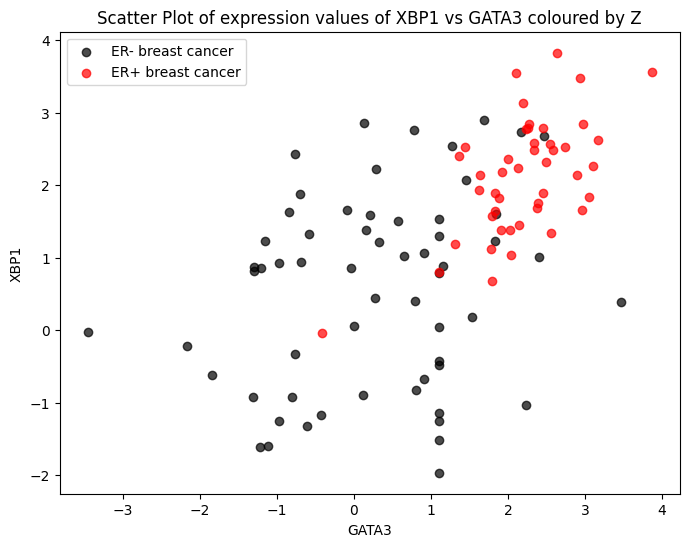

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('filtered.tsv', sep='\t')
df1 = pd.read_csv('class.tsv', sep='\t', header=None)
mapping = pd.read_csv('columns.tsv', sep='\t',skiprows=18)
# Extracting the ID of XBP1 and GATA3 from the mapping dataframe
X = mapping.loc[mapping['GeneSymbol'] == 'GATA3', 'ID'].values[0]
Y = mapping.loc[mapping['GeneSymbol'] == 'XBP1', 'ID'].values[0]
# Convert X and Y to string
X = " " + str(X)
Y = " " + str(Y)
X = df[X]
Y = df[Y] 
Z = df1.iloc[:,0]
c1 = (Z == 0)
c2 = (Z == 1)
# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X[c1], Y[c1], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(X[c2], Y[c2], color='red', alpha=0.7, label='ER+ breast cancer') 
plt.xlabel('GATA3')
plt.ylabel('XBP1')
plt.title('Scatter Plot of expression values of XBP1 vs GATA3 coloured by Z')
plt.legend()
plt.show()

##### **B. Finding and plotting the principle components**

**PCA Steps :**
- The data is first centered by subtracting the mean of column from its values, ensuring the origin is at the data centroid.
- The covariance matrix of the centered data is computed to capture how the two variables vary together.
- Eigenvalues and eigenvectors of the covariance matrix are calculated:
  - Eigenvectors represent the principal components which shows the directions of maximum variance.
  - Eigenvalues indicate the amount of variance captured along each principal component.
- The eigenvectors are sorted in descending order of eigenvalues, so the first principal component (PC1) captures the most variance.
- In the scatter plot, PCA vectors are plotted as arrows originating from the mean point, showing the directions in which the data varies the most.

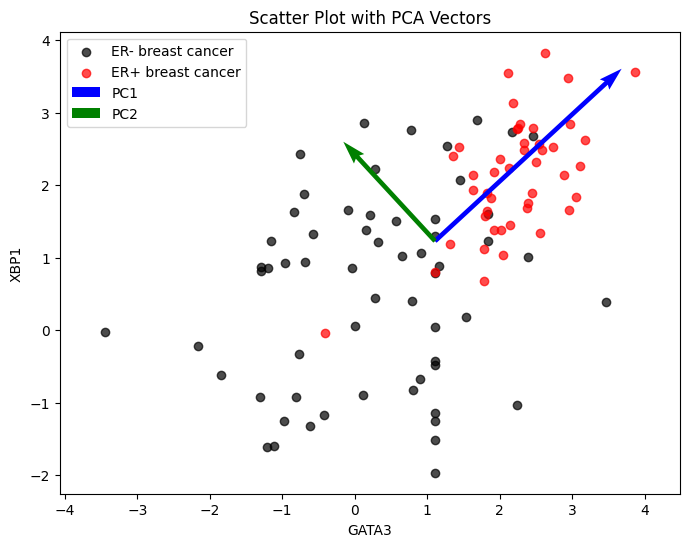

In [2]:
# Combine into 2D data matrix and center it
data = np.vstack((X, Y)).T
mean = np.mean(data, axis=0)
centered_data = data - mean

# PCA from scratch
cov_matrix = np.cov(centered_data.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvectors by descending eigenvalues
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Split classes for plotting
c1 = (Z == 0)
c2 = (Z == 1)

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X[c1], Y[c1], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(X[c2], Y[c2], color='red', alpha=0.7, label='ER+ breast cancer') 
plt.xlabel('GATA3')
plt.ylabel('XBP1')
plt.title('Scatter Plot with PCA Vectors')

# Plot eigenvectors (scaled for visibility)
for i in range(2):
    vec = eigenvectors[:, i]
    scale = np.sqrt(eigenvalues[i]) * 2  # Adjust scale for visibility
    plt.quiver(mean[0], mean[1], vec[0]*scale, vec[1]*scale, 
               angles='xy', scale_units='xy', scale=1, 
               color='blue' if i == 0 else 'green', 
               label=f'PC{i+1}')

plt.legend()
plt.axis('equal')
plt.show()

##### **C. Plotting the Projection of the datapoints on PC1 to get fig. 1(c)**

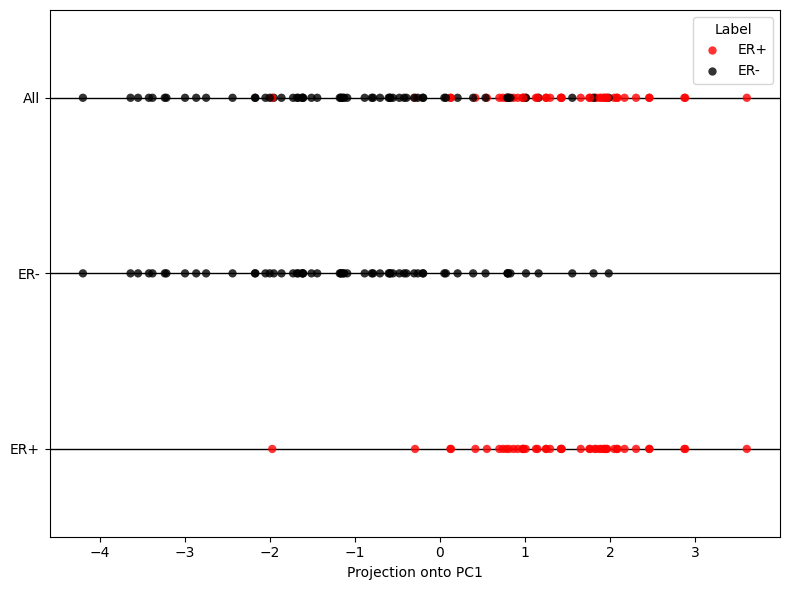

In [7]:
pc1 = centered_data @ eigenvectors[:, 0] 
class_labels = Z.map({0: 'ER-', 1: 'ER+'})
proj_df = pd.DataFrame({'PC1': pc1, 'Label': class_labels})

# Create 3 groups: All, ER-, ER+
proj_all = proj_df.copy()
proj_all['Group'] = 'All'

proj_er_neg = proj_df[class_labels == 'ER-'].copy()
proj_er_neg['Group'] = 'ER-'

proj_er_pos = proj_df[class_labels == 'ER+'].copy()
proj_er_pos['Group'] = 'ER+'

# Combine all into one dataframe for plotting
plot_df = pd.concat([proj_all, proj_er_neg, proj_er_pos], ignore_index=True)

# Plot
plt.figure(figsize=(8, 6))
plot = sns.stripplot(data=plot_df,x='PC1',y='Group',hue='Label',palette={'ER-': 'black', 'ER+': 'red'},
              dodge=False,jitter=False,size=6,alpha=0.8,orient='h')
plot.yaxis.grid(True, linestyle='-', color='black', linewidth=1, alpha=1.0) 
plt.xlabel('Projection onto PC1')
plt.ylabel('')
plt.tight_layout()
plt.show()